loss: 0.15971557796001434 epoch: 0
loss: 0.000958033197093755 epoch: 500
loss: 0.00024047386250458658 epoch: 1000
loss: 7.67737437854521e-05 epoch: 1500
loss: 1.1167035154358018e-05 epoch: 2000
loss: 6.817803659942001e-05 epoch: 2500
loss: 7.039018964860588e-05 epoch: 3000
loss: 5.712120037060231e-05 epoch: 3500
loss: 9.081402095034719e-05 epoch: 4000
loss: 6.242055860639084e-06 epoch: 4500


[]

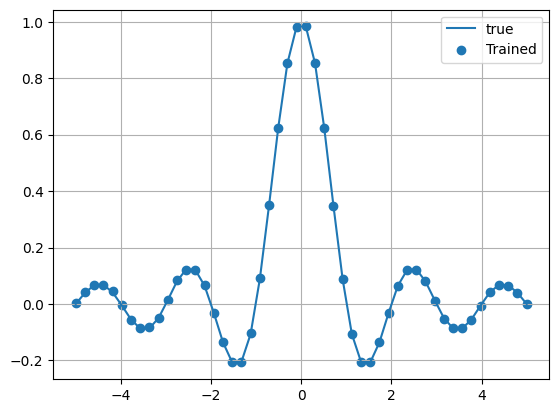

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

x=torch.linspace(-5,5,50).view(-1,1)
y=torch.where(x==0,torch.ones_like(x),torch.sin(torch.pi*x)/(torch.pi*x)).view(-1,1)

class Net(nn.Module):
  def __init__(self):
    super(Net,self).__init__()
    self.input=nn.Linear(1,32)
    self.l1=nn.Linear(32,32)
    self.l2=nn.Linear(32,32)
    self.l3=nn.Linear(32,32)
    self.output=nn.Linear(32,1)

  def forward(self,x):
    x=self.input(x)
    x=torch.tanh(self.l1(x))
    x=torch.tanh(self.l2(x))
    x=torch.tanh(self.l3(x))
    x=self.output(x)

    return x

model=Net()
optimizer=optim.Adam(model.parameters(),lr=0.01)
criterion=nn.MSELoss()
for epoch in range(5000):
  optimizer.zero_grad()
  pred=model(x)
  loss=criterion(pred,y)
  loss.backward()
  optimizer.step()

  if epoch%500==0:
    print('loss:',loss.item(),'epoch:',epoch)

with torch.no_grad():
  ypred=model(x)

plt.figure()
y=y.reshape(50)
plt.plot(x,y,label='true')
plt.scatter(x,ypred,label='Trained')
plt.legend()
plt.grid(True)
plt.plot()

loss: 0.11003715544939041 epoch: 0
loss: 0.016409318894147873 epoch: 500
loss: 0.01660413108766079 epoch: 1000
loss: 0.014363768510520458 epoch: 1500
loss: 0.012597796507179737 epoch: 2000
loss: 0.012869907543063164 epoch: 2500
loss: 0.012818778865039349 epoch: 3000
loss: 0.01342425961047411 epoch: 3500
loss: 0.013029682449996471 epoch: 4000
loss: 0.012382900342345238 epoch: 4500


[]

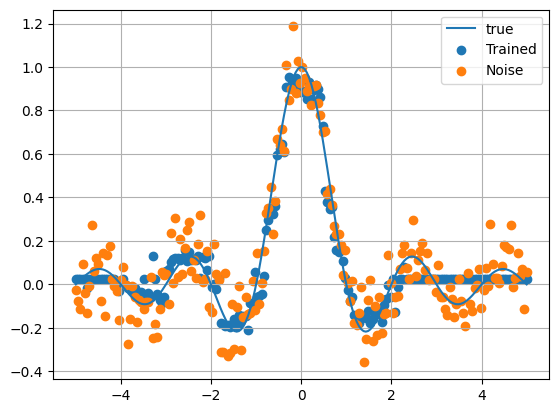

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

x=torch.linspace(-5,5,200).view(-1,1)
y_clean=torch.where(x==0,torch.ones_like(x),torch.sin(torch.pi*x)/(torch.pi*x))
noise=torch.randn_like(y_clean)*0.1
y_noisy=y_clean+noise


class Net(nn.Module):
  def __init__(self):
    super(Net,self).__init__()
    self.input=nn.Linear(1,64)
    self.h1=nn.Linear(64,64)
    self.h2=nn.Linear(64,64)
    self.h3=nn.Linear(64,64)
    self.output=nn.Linear(64,1)
    self.dropout=nn.Dropout(p=0.2)

  def forward(self,x):
    x=torch.relu(self.input(x))
    x=self.dropout(x)
    x=torch.relu(self.h1(x))
    x=self.dropout(x)
    x=torch.relu(self.h2(x))
    x=self.dropout(x)
    x=torch.relu(self.h3(x))
    x=self.output(x)

    return x

model=Net()
optimizer=optim.Adam(model.parameters(),lr=0.01)
criterion=nn.MSELoss()
for epoch in range(5000):
  optimizer.zero_grad()
  pred=model(x)
  loss=criterion(pred,y_noisy)
  loss.backward()
  optimizer.step()

  if epoch%500==0:
    print('loss:',loss.item(),'epoch:',epoch)

with torch.no_grad():
  ypred=model(x)

plt.figure()
y_clean=y_clean.reshape(200)
y_noisy=y_noisy.reshape(200)
plt.plot(x,y_clean,label='true')
plt.scatter(x,ypred,label='Trained')
plt.scatter(x,y_noisy,label='Noise')
plt.legend()
plt.grid(True)
plt.plot()

loss: 0.2237464338541031 epoch: 0
loss: 0.011408486403524876 epoch: 500
loss: 0.009107028134167194 epoch: 1000
loss: 0.008603718131780624 epoch: 1500
loss: 0.008435900323092937 epoch: 2000
loss: 0.008286379277706146 epoch: 2500
loss: 0.008175290189683437 epoch: 3000
loss: 0.008107850328087807 epoch: 3500
loss: 0.008014867082238197 epoch: 4000
loss: 0.007966229692101479 epoch: 4500


[]

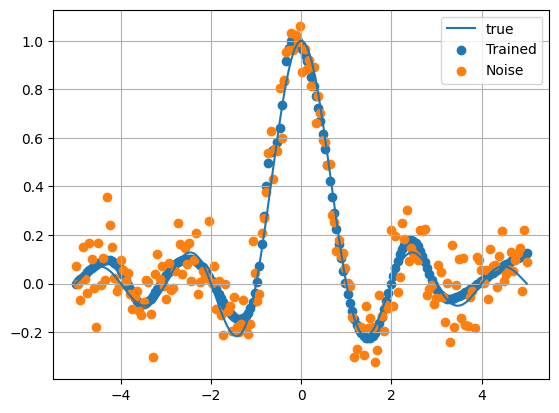

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

x=torch.linspace(-5,5,200).view(-1,1)
y_clean=torch.where(x==0,torch.ones_like(x),torch.sin(torch.pi*x)/(torch.pi*x))
noise=torch.randn_like(y_clean)*0.1
y_noisy=y_clean+noise


class Net(nn.Module):
  def __init__(self):
    super(Net,self).__init__()
    self.input=nn.Linear(1,16)
    self.h1=nn.Linear(16,16)
    self.output=nn.Linear(16,1)

  def forward(self,x):
    x=torch.tanh(self.input(x))
    x=torch.tanh(self.h1(x))
    x=self.output(x)

    return x

model=Net()
optimizer=optim.Adam(model.parameters(),lr=0.01)
criterion=nn.MSELoss()
for epoch in range(5000):
  optimizer.zero_grad()
  pred=model(x)
  loss=criterion(pred,y_noisy)
  loss.backward()
  optimizer.step()

  if epoch%500==0:
    print('loss:',loss.item(),'epoch:',epoch)

with torch.no_grad():
  ypred=model(x)

plt.figure()
y_clean=y_clean.reshape(200)
y_noisy=y_noisy.reshape(200)
plt.plot(x,y_clean,label='true')
plt.scatter(x,ypred,label='Trained')
plt.scatter(x,y_noisy,label='Noise')
plt.legend()
plt.grid(True)
plt.plot()

loss: 0.1172473207116127 epoch: 0
loss: 0.011229097843170166 epoch: 500
loss: 0.010900943540036678 epoch: 1000
loss: 0.009881178848445415 epoch: 1500
loss: 0.009835959412157536 epoch: 2000
loss: 0.010720839723944664 epoch: 2500
loss: 0.009783579967916012 epoch: 3000
loss: 0.009731374680995941 epoch: 3500
loss: 0.009618599899113178 epoch: 4000
loss: 0.009419175796210766 epoch: 4500


[]

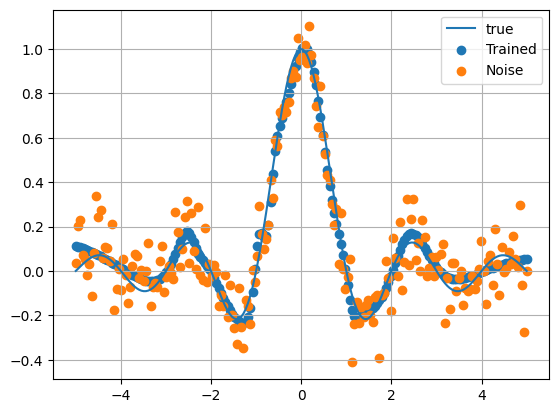

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

x=torch.linspace(-5,5,200).view(-1,1)
y_clean=(torch.sin(torch.pi*x)/(torch.pi*x))
noise=torch.randn_like(y_clean)*0.1
y_noisy=y_clean+noise


class Net(nn.Module):
  def __init__(self):
    super(Net,self).__init__()
    self.input=nn.Linear(1,16)
    self.h1=nn.Linear(16,16)
    self.output=nn.Linear(16,1)

  def forward(self,x):
    x=torch.tanh(self.input(x))
    x=torch.tanh(self.h1(x))
    x=self.output(x)

    return x

model=Net()
optimizer=optim.Adam(model.parameters(),lr=0.01)
criterion=nn.MSELoss()
for epoch in range(5000):
  optimizer.zero_grad()
  pred=model(x)
  loss=criterion(pred,y_noisy)
  loss.backward()
  optimizer.step()

  if epoch%500==0:
    print('loss:',loss.item(),'epoch:',epoch)

with torch.no_grad():
  ypred=model(x)

plt.figure()
y_clean=y_clean.reshape(200)
y_noisy=y_noisy.reshape(200)
plt.plot(x,y_clean,label='true')
plt.scatter(x,ypred,label='Trained')
plt.scatter(x,y_noisy,label='Noise')
plt.legend()
plt.grid(True)
plt.plot()

Observations:

1. torch.where handles discontinuities cleanly at the data level
2. Boundary effects cause edge struggles on any finite domain
3. Tanh saturates at large inputs → vanishing gradients → poor edge fitting
4. ReLU avoids saturation → better gradient flow → better edge fitting